In [ ]:
import numpy as np 
import matplotlib.pyplot as plt

import h5py
from tqdm import tqdm

root = "/home/ndm33/aispp-sims/gaussian-wavefront-spatially-resolved-inference/data/R80_N50_A1000000_muXStd10.0um_muVxStd10.0um_sigX100um_sigVx309um_sigXStd10.0um_sigVxStd10.0um_phi0random_sig_A0.100_f0.3000/"
run_numbers = list(range(50))  # e.g. [18] loads run_018
n_runs = len(run_numbers)

n0_z0 = np.zeros((n_runs, 50))
N_z0 = np.zeros((n_runs, 50))
n0_z100 = np.zeros((n_runs, 50))
N_z100 = np.zeros((n_runs, 50))
mean_x_z0 = np.zeros((n_runs, 50))
mean_y_z0 = np.zeros((n_runs, 50))
std_x_z0 = np.zeros((n_runs, 50))
std_y_z0 = np.zeros((n_runs, 50))
mean_x_z100 = np.zeros(n_runs)
mean_y_z100 = np.zeros(n_runs)
std_x_z100 = np.zeros(n_runs)
std_y_z100 = np.zeros(n_runs)

for i, run_number in enumerate(tqdm(run_numbers)):
    run_name = f"run_{int(run_number):03d}"
    path_z0   = root + run_name + "/Z0/data_IMG.h5"
    path_z100 = root + run_name + "/Z100/data_IMG.h5"
    with h5py.File(path_z0, "r") as f:
        s0 = f['images_s0'][()]
        s1 = f['images_s1'][()]

        # compute n0, N
        n0 = np.sum(np.sum(s0, axis=1), axis=1)
        n1 = np.sum(np.sum(s1, axis=1), axis=1)

        n0_z0[i] = n0
        N_z0[i] = n0 + n1

        # compute the mean and std in x and y
        pos  = np.linspace(-1, 1, 2048)
        x_profile = np.sum(s0, axis=2)
        y_profile = np.sum(s0, axis=1)
        mu_x = np.sum(x_profile * pos, axis=1) / n0
        mu_y = np.sum(y_profile * pos, axis=1) / n0
        var_x = np.sum(x_profile * (pos - mu_x[:, None])**2, axis=1) / n0
        var_y = np.sum(y_profile * (pos - mu_y[:, None])**2, axis=1) / n0

        mean_x_z0[i] = mu_x
        mean_y_z0[i] = mu_y
        std_x_z0[i] = np.sqrt(np.clip(var_x, 0, None))
        std_y_z0[i] = np.sqrt(np.clip(var_y, 0, None))


100%|██████████| 50/50 [01:23<00:00,  1.68s/it]


In [35]:
import sys
sys.path.insert(0, "../helpers/")
from helpers import ImageShotDataset
from fitting import fit_from_datasets

count_mle_results = []
for run_number in tqdm(run_numbers):
    Z0 = ImageShotDataset(f"{root}run_{run_number:03d}/Z0/data_IMG.h5")
    Z100 = ImageShotDataset(f"{root}run_{run_number:03d}/Z100/data_IMG.h5")
    count_mle_results.append(fit_from_datasets(Z0, Z100, f=0.3))

  0%|          | 0/50 [01:05<?, ?it/s]


KeyboardInterrupt: 

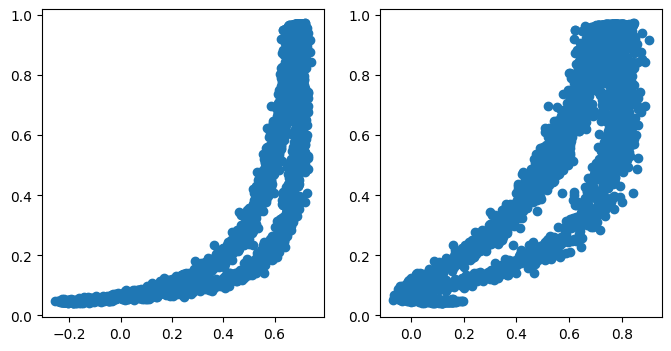

In [32]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# first fit linear
ols_model = LinearRegression()
y = (n0_z0/N_z0).flatten()
X_linear = np.vstack([mean_x_z0.flatten(), mean_y_z0.flatten(), std_x_z0.flatten(), std_y_z0.flatten()]).T
_=ols_model.fit(X_linear,y)

ypred_linear = ols_model.predict(X_linear)

# fit polynomial features
X_quad = PolynomialFeatures(degree=2).fit_transform(X_linear)
quad_model = LinearRegression()
_=quad_model.fit(X_quad, y)

ypred_quad = quad_model.predict(X_quad)

fig, axs = plt.subplots(1,2, figsize=(8,4))
axs[0].scatter(ypred_linear, y)
axs[1].scatter(ypred_quad, y)